# Proyecto Final: Transformación y Modelado de Indicadores Socioeconómicos en Latinoamérica

**Curso:** CC3074 - Minería de Datos  
**Framework:** CRISP-DM - Fase 1: Comprensión del Negocio y los Datos  
**Fuente de datos:** CEPALSTAT - Observatorio de Desarrollo Digital (ODD)  
**Indicador:** Personas usuarias de Internet por grupo etario, países seleccionados de América Latina y el Caribe  

**Integrantes:** 
 
- Cristian Túnchez (231359)  
- Dulce Ambrosio (231143)  
- Daniel Chet (231177)  
- Javier Linares (231135)  

## Semana 1 - Análisis Exploratorio de Datos: Uso de Internet por Grupo Etario en América Latina (2000-2022)

---
### Contexto del "Negocio"

El acceso a Internet es un indicador clave de desarrollo digital y social. Este conjunto de datos, publicado por la Comision Economica para America Latina y el Caribe (CEPAL), mide el porcentaje de personas que utilizan Internet en 14 países latinoaméricanos, desglosado por grupo etario, a lo largo de más de dos decadas (2000-2022).

Comprender los patrones de adopción digital, las brechas entre grupos de edad y las diferencias entre países es fundamental para:

- Políticas públicas de inclusión digital
- Estrategias de alfabetización tecnológica
- Análisis de la brecha digital intergeneracional

**Objetivo del EDA:** Explorar la estructura, calidad y patrones principales del dataset para identificar problemas de datos y formular hipótesis para fases posteriores de Minería de Datos.

**Configuración del entorno e importación de librerías**

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator
from scipy import stats as sp_stats
import warnings

warnings.filterwarnings('ignore')

# Configuracion visual
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
sns.set_style('whitegrid')
sns.set_palette('Set2')

# Paleta personalizada para grupos etarios (de joven a mayor)
PALETA_EDAD = {
    'edad de medicion a 17 años': '#2196F3',
    '18 a 25 años de edad': '#4CAF50',
    '26 a 50 años de edad': '#FF9800',
    '51 a 65 años': '#F44336',
    '66 años en adelante': '#9C27B0',
    'Total': '#607D8B'
}

ORDEN_EDAD = [
    'edad de medicion a 17 años',
    '18 a 25 años de edad',
    '26 a 50 años de edad',
    '51 a 65 años',
    '66 años en adelante',
    'Total'
]

# Etiquetas cortas para gráficos
ETIQUETAS_CORTAS = {
    'edad de medicion a 17 años': '<=17 años',
    '18 a 25 años de edad': '18-25',
    '26 a 50 años de edad': '26-50',
    '51 a 65 años': '51-65',
    '66 años en adelante': '66+',
    'Total': 'Total'
}

print('Entorno configurado correctamente.')
print(f'pandas: {pd.__version__}')
print(f'numpy: {np.__version__}')

Entorno configurado correctamente.
pandas: 3.0.0
numpy: 2.4.2


**Carga de datos desde el archivo Excel**

In [40]:
df = pd.read_excel('data.xlsx', sheet_name='datos')
metadatos = pd.read_excel('data.xlsx', sheet_name='metadatos')
fuentes = pd.read_excel('data.xlsx', sheet_name='fuentes')
notas = pd.read_excel('data.xlsx', sheet_name='notas')
creditos = pd.read_excel('data.xlsx', sheet_name='creditos')

print(f'Dataset principal cargado: {df.shape[0]} filas x {df.shape[1]} columnas')
print(f'\nHojas auxiliares cargadas:')
print(f'  metadatos: {metadatos.shape}')
print(f'  fuentes:   {fuentes.shape}')
print(f'  notas:     {notas.shape}')
print(f'  créditos:  {creditos.shape}')

Dataset principal cargado: 870 filas x 8 columnas

Hojas auxiliares cargadas:
  metadatos: (12, 2)
  fuentes:   (1, 6)
  notas:     (0, 1)
  créditos:  (4, 2)


---
### 1. Descripción General del Conjunto de Datos

En esta sección se describe la estructura del dataset: el significado y tipo de cada variable, la cantidad de observaciones y variables, y se examinan los metadatos proporcionados por CEPAL.

**Vista general del dataset**

In [41]:
print('=' * 70)
print('ESTRUCTURA DEL DATASET')
print('=' * 70)
print(f'\nDimensiones: {df.shape[0]} observaciones x {df.shape[1]} variables')
print(f'\nColumnas y tipos de datos:')
print('-' * 50)
df.info()

ESTRUCTURA DEL DATASET

Dimensiones: 870 observaciones x 8 variables

Columnas y tipos de datos:
--------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 870 entries, 0 to 869
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   indicator                    870 non-null    str    
 1   País__ESTANDAR               870 non-null    str    
 2   Grupos etarios Uso Internet  870 non-null    str    
 3   Años__ESTANDAR               870 non-null    int64  
 4   value                        870 non-null    float64
 5   unit                         870 non-null    str    
 6   notes_ids                    0 non-null      float64
 7   source_id                    870 non-null    int64  
dtypes: float64(2), int64(2), str(4)
memory usage: 54.5 KB


**Primeras y últimas observaciones**

In [42]:
print('Primeras 5 filas:')
display(df.head())

print('\nÚltimas 5 filas:')
display(df.tail())

Primeras 5 filas:


,indicator,País__ESTANDAR,Grupos etarios Uso Internet,Años__ESTANDAR,value,unit,notes_ids,source_id
0,Personas usuarias de Internet por grupo etario...,Argentina,edad de medicion a 17 años,2016,75.9,Porcentaje sobre el total de personas en cada ...,NaN,9353
1,Personas usuarias de Internet por grupo etario...,Argentina,edad de medicion a 17 años,2017,75.9,Porcentaje sobre el total de personas en cada ...,NaN,9353
2,Personas usuarias de Internet por grupo etario...,Argentina,edad de medicion a 17 años,2018,78.5,Porcentaje sobre el total de personas en cada ...,NaN,9353
3,Personas usuarias de Internet por grupo etario...,Argentina,edad de medicion a 17 años,2019,78.9,Porcentaje sobre el total de personas en cada ...,NaN,9353
4,Personas usuarias de Internet por grupo etario...,Argentina,edad de medicion a 17 años,2020,87.5,Porcentaje sobre el total de personas en cada ...,NaN,9353



Últimas 5 filas:


,indicator,País__ESTANDAR,Grupos etarios Uso Internet,Años__ESTANDAR,value,unit,notes_ids,source_id
865,Personas usuarias de Internet por grupo etario...,Uruguay,Total,2015,64.6,Porcentaje sobre el total de personas en cada ...,NaN,9353
866,Personas usuarias de Internet por grupo etario...,Uruguay,Total,2016,71.9,Porcentaje sobre el total de personas en cada ...,NaN,9353
867,Personas usuarias de Internet por grupo etario...,Uruguay,Total,2017,76.7,Porcentaje sobre el total de personas en cada ...,NaN,9353
868,Personas usuarias de Internet por grupo etario...,Uruguay,Total,2018,80.7,Porcentaje sobre el total de personas en cada ...,NaN,9353
869,Personas usuarias de Internet por grupo etario...,Uruguay,Total,2019,83.4,Porcentaje sobre el total de personas en cada ...,NaN,9353


#### 1.1 Significado y Tipo de Cada Variable

| # | Variable | Tipo en pandas | Tipo conceptual | Descripción |
|---|----------|---------------|-----------------|-------------|
| 1 | `indicator` | object (string) | Categórica nominal (constante) | Nombre descriptivo del indicador. **Valor unico** para todas las filas. |
| 2 | `País__ESTANDAR` | object (string) | Categórica nominal | Nombre del país (14 paises latinoamericanos). |
| 3 | `Grupos etarios Uso Internet` | object (string) | Categórica ordinal | Grupo de edad: menores de 17, 18-25, 26-50, 51-65, 66+, y Total. |
| 4 | `Años__ESTANDAR` | int64 | Temporal (discreta) | Año de medicion (2000, 2003-2022). |
| 5 | `value` | float64 | Numérica continua | **Variable objetivo:** Porcentaje de personas usuarias de Internet en cada grupo etario. Rango [0, 100]. |
| 6 | `unit` | object (string) | Categórica nominal (constante) | Unidad de medida. **Valor único** para todas las filas. |
| 7 | `notes_ids` | float64 | Identificador | Identificadores de notas. **100% nulo** en este dataset. |
| 8 | `source_id` | int64 | Identificador (constante) | ID de la fuente de datos. **Valor unico** (9353) para todas las filas. |

**Observaciones clave sobre las variables:**
- Solo **1 variable es realmente numérica** (`value`) - el porcentaje de uso de Internet.
- **4 variables son constantes o nulas** (`indicator`, `unit`, `source_id`, `notes_ids`) y no aportan información diferenciadora.
- Las **3 variables categóricas informativas** (`País__ESTANDAR`, `Grupos etarios Uso Internet`, `Años__ESTANDAR`) definen las dimensiones del panel de datos.
- El dataset tiene estructura de **datos de panel**: País x Grupo Etario x Año.

**Valores únicos por columna**

In [43]:
print('=' * 70)
print('VALORES ÚNICOS POR VARIABLE')
print('=' * 70)

for col in df.columns:
    n_unique = df[col].nunique()
    n_null = df[col].isnull().sum()
    pct_null = (n_null / len(df)) * 100
    print(f'\n{"─" * 50}')
    print(f'{col}')
    print(f'   Valores únicos: {n_unique} | Nulos: {n_null} ({pct_null:.1f}%)')
    if n_unique <= 25:
        print(f'   Valores: {sorted(df[col].dropna().unique().tolist(), key=str)}')
    else:
        print(f'   Ejemplo: {df[col].dropna().iloc[0]}')

VALORES ÚNICOS POR VARIABLE

──────────────────────────────────────────────────
indicator
   Valores únicos: 1 | Nulos: 0 (0.0%)
   Valores: ['Personas usuarias de Internet por grupo etario, países seleccionados América Latina y el Caribe, 2000 a 2022']

──────────────────────────────────────────────────
País__ESTANDAR
   Valores únicos: 14 | Nulos: 0 (0.0%)
   Valores: ['Argentina', 'Bolivia (Estado Plurinacional de)', 'Brasil', 'Chile', 'Colombia', 'Costa Rica', 'Ecuador', 'El Salvador', 'Honduras', 'México', 'Panamá', 'Paraguay', 'Perú', 'Uruguay']

──────────────────────────────────────────────────
Grupos etarios Uso Internet
   Valores únicos: 6 | Nulos: 0 (0.0%)
   Valores: ['18 a 25 años de edad', '26 a 50 años de edad', '51 a 65 años', '66 años en adelante', 'Total', 'edad de medicion a 17 años']

──────────────────────────────────────────────────
Años__ESTANDAR
   Valores únicos: 21 | Nulos: 0 (0.0%)
   Valores: [2000, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012

**Metadatos del indicador (de la hoja 'metadatos')**

In [44]:
print('=' * 70)
print('METADATOS DEL INDICADOR')
print('=' * 70)
display(metadatos)

print('\n' + '=' * 70)
print('FUENTE DE DATOS')
print('=' * 70)
display(fuentes)

print('\n' + '=' * 70)
print('CRÉDITOS')
print('=' * 70)
display(creditos)

METADATOS DEL INDICADOR


,metadata,value
0,indicator_id,4987
1,indicator_name,Personas usuarias de Internet por grupo etario...
2,theme,Tecnologías de Información y Comunicación
3,area,Uso individual de TIC
4,note,El uso de Internet se miden en Argentina a par...
5,unit,Porcentaje sobre el total de personas en cada ...
6,data_features,NaN
7,definition,Personas usuarias de Internet por grupo etario...
8,calculation_methodology,100*(Cantidad de usuarios de Internet en cada ...
9,comments,NaN



FUENTE DE DATOS


,id,organization_name,description,organization_url,organization_acronym,publication_url
0,9353,Comisión Económica para América Latina y el Ca...,Observatorio de Desarrollo Digital (ODD) sobre...,http://www.eclac.org/,CEPAL,NaN



CRÉDITOS


,id,description
0,0,2026-04-25
1,1,CEPALSTAT
2,2,Comisión Económica para América Latina y el Ca...
3,3,Naciones Unidas


#### 1.2 Problemas de Calidad de Datos Identificados

1. **Variables redundantes/constantes (4 de 8):**
   - `indicator`: Valor idéntico en todas las filas. No aporta variabilidad.
   - `unit`: Valor idéntico en todas las filas ("Porcentaje sobre el total de personas en cada grupo etario").
   - `source_id`: Valor idéntico en todas las filas (9353).
   - `notes_ids`: **100% nulo** - columna completamente vacía.
   
2. **Datos de panel incompletos:**
   - El producto cruzado completo (14 países x 21 años x 6 grupos etarios) sería 1,764 registros.
   - Solo hay 870 registros: **completitud del 49.3%**.
   - Cada país tiene datos para diferentes rangos de años.
   
3. **Heterogeneidad en la edad de medición:**
   - Según los metadatos, la edad mínima de medición varía por país:
     - 4 años: Argentina
     - 5 años: Bolivia, Chile, Colombia, Costa Rica, Ecuador, Honduras
     - 6 años: Uruguay, Perú
     - 10 años: Brasil, El Salvador, Panamá, Paraguay
   - Esto afecta la comparabilidad del grupo "edad de medición a 17 años".

4. **Cobertura temporal desigual:**
   - Algunos países tienen datos para 17 años; otros solo para 7.
   - Hay brechas temporales significativas dentro de los países.

5. **Tipo de dato de `Años__ESTANDAR`:** Cargado como `int64`, pero podría convertirse a `datetime` para análisis de series temporales.

**Mapa de calor de cobertura temporal por país**

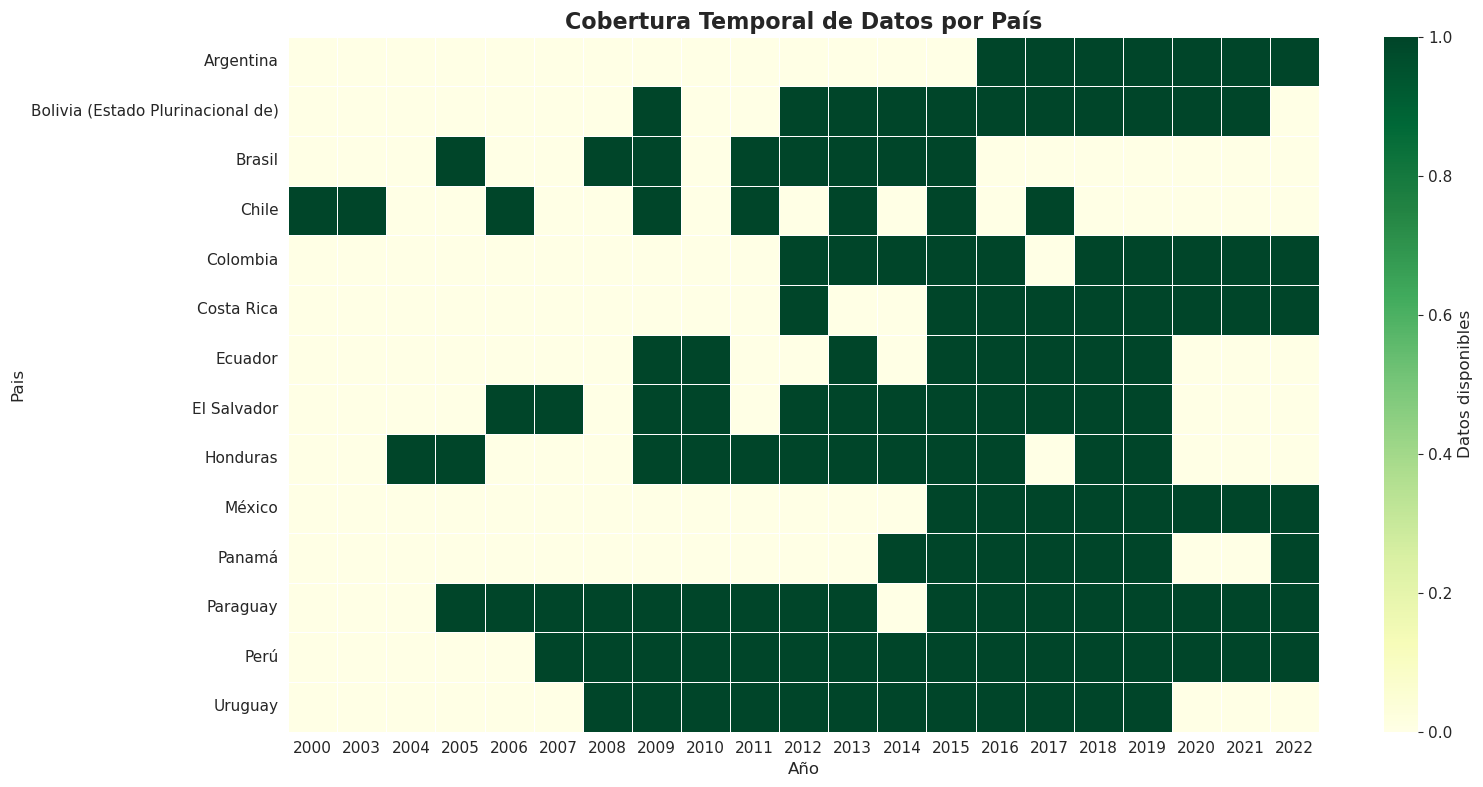


Completitud del dataset: 870 / 1764 posibles = 49.3%


In [45]:
fig, ax = plt.subplots(figsize=(16, 8))

# Crear matriz de presencia de datos
coverage = df.groupby(['País__ESTANDAR', 'Años__ESTANDAR']).size().unstack(fill_value=0)
coverage = (coverage > 0).astype(int)

sns.heatmap(coverage, cmap='YlGn', cbar_kws={'label': 'Datos disponibles'},
            linewidths=0.5, linecolor='white', ax=ax,
            xticklabels=True, yticklabels=True)
ax.set_title('Cobertura Temporal de Datos por País', fontsize=16, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Pais')
plt.tight_layout()
plt.show()

total_posible = 14 * 21 * 6
print(f'\nCompletitud del dataset: {len(df)} / {total_posible} posibles = {len(df)/total_posible*100:.1f}%')

**Cantidad de observaciones por país**

,observaciones,año_min,año_max,años_distintos
País__ESTANDAR,,,,
Paraguay,102,2005,2022,17
Perú,96,2007,2022,16
Honduras,72,2004,2019,12
El Salvador,72,2006,2019,12
Uruguay,72,2008,2019,12
Bolivia (Estado Plurinacional de),66,2009,2021,11
Colombia,60,2012,2022,10
Costa Rica,54,2012,2022,9
Chile,48,2000,2017,8


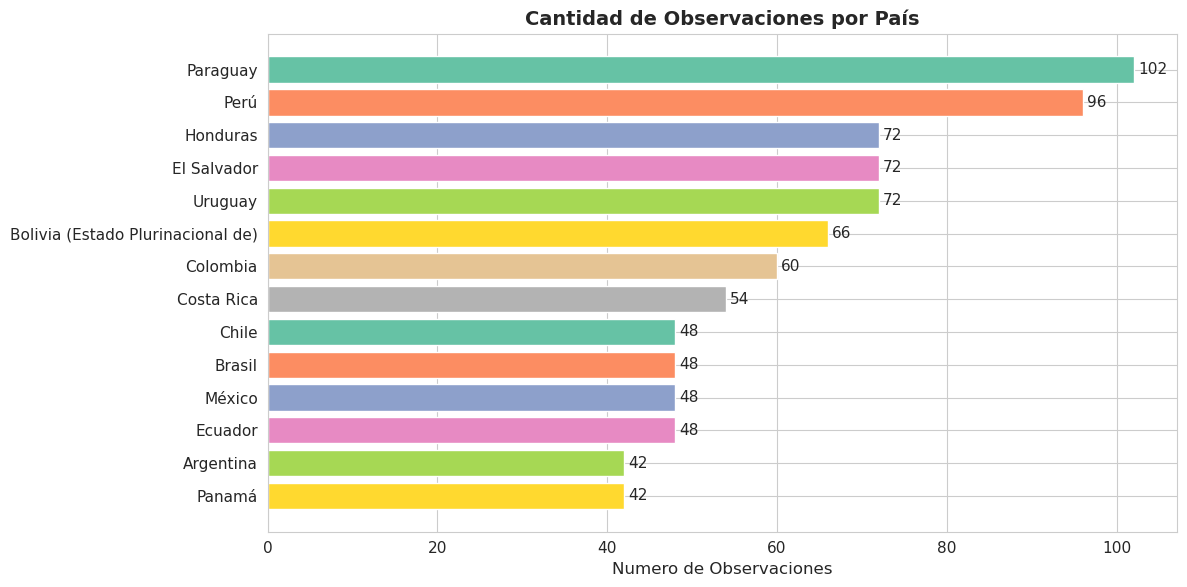

In [46]:
obs_pais = df.groupby('País__ESTANDAR').agg(
    observaciones=('value', 'count'),
    año_min=('Años__ESTANDAR', 'min'),
    año_max=('Años__ESTANDAR', 'max'),
    años_distintos=('Años__ESTANDAR', 'nunique')
).sort_values('observaciones', ascending=False)

display(obs_pais)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(obs_pais.index, obs_pais['observaciones'], color=sns.color_palette('Set2', len(obs_pais)))
ax.set_xlabel('Numero de Observaciones')
ax.set_title('Cantidad de Observaciones por País', fontsize=14, fontweight='bold')
ax.bar_label(bars, padding=3)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
### 2. Exploración de Variables Numéricas

El dataset contiene una única variable numérica: `value`, que representa el porcentaje de personas usuarias de Internet en cada grupo etario. A pesar de tener solo una variable numérica, su análisis es enriquecedor porque puede segmentarse por las tres dimensiones del panel: país, grupo etario y año.

#### 2.1 Medidas de Tendencia Central, Distribución y Orden

**Estadísticas descriptivas globales de 'value'**

In [47]:
print('=' * 70)
print('ESTADISTICAS DESCRIPTIVAS: variable "value"')
print('=' * 70)

stats = df['value'].describe()
stats['varianza'] = df['value'].var()
stats['rango'] = df['value'].max() - df['value'].min()
stats['IQR'] = df['value'].quantile(0.75) - df['value'].quantile(0.25)
stats['coef_variacion'] = (df['value'].std() / df['value'].mean()) * 100
stats['asimetria'] = df['value'].skew()
stats['curtosis'] = df['value'].kurtosis()

display(pd.DataFrame(stats, columns=['Valor']).round(4))

print(f'\nInterpretacion:')
print(f'  - La media ({stats["mean"]:.1f}%) indica que, en promedio, menos de la mitad de la poblacion usa Internet.')
print(f'  - La mediana ({stats["50%"]:.1f}%) es cercana a la media, sugiriendo simetria aproximada.')
print(f'  - El coeficiente de variacion ({stats["coef_variacion"]:.1f}%) indica alta dispersion relativa.')
print(f'  - La curtosis ({stats["curtosis"]:.2f}) es negativa (platikurtica): distribucion mas plana que la normal.')
print(f'  - La asimetria ({stats["asimetria"]:.4f}) es cercana a cero: distribucion aproximadamente simetrica.')

ESTADISTICAS DESCRIPTIVAS: variable "value"


,Valor



Interpretacion:
  - La media (44.8%) indica que, en promedio, menos de la mitad de la poblacion usa Internet.
  - La mediana (45.2%) es cercana a la media, sugiriendo simetria aproximada.
  - El coeficiente de variacion (62.1%) indica alta dispersion relativa.
  - La curtosis (-1.27) es negativa (platikurtica): distribucion mas plana que la normal.
  - La asimetria (0.0342) es cercana a cero: distribucion aproximadamente simetrica.


**Distribución global de 'value'**

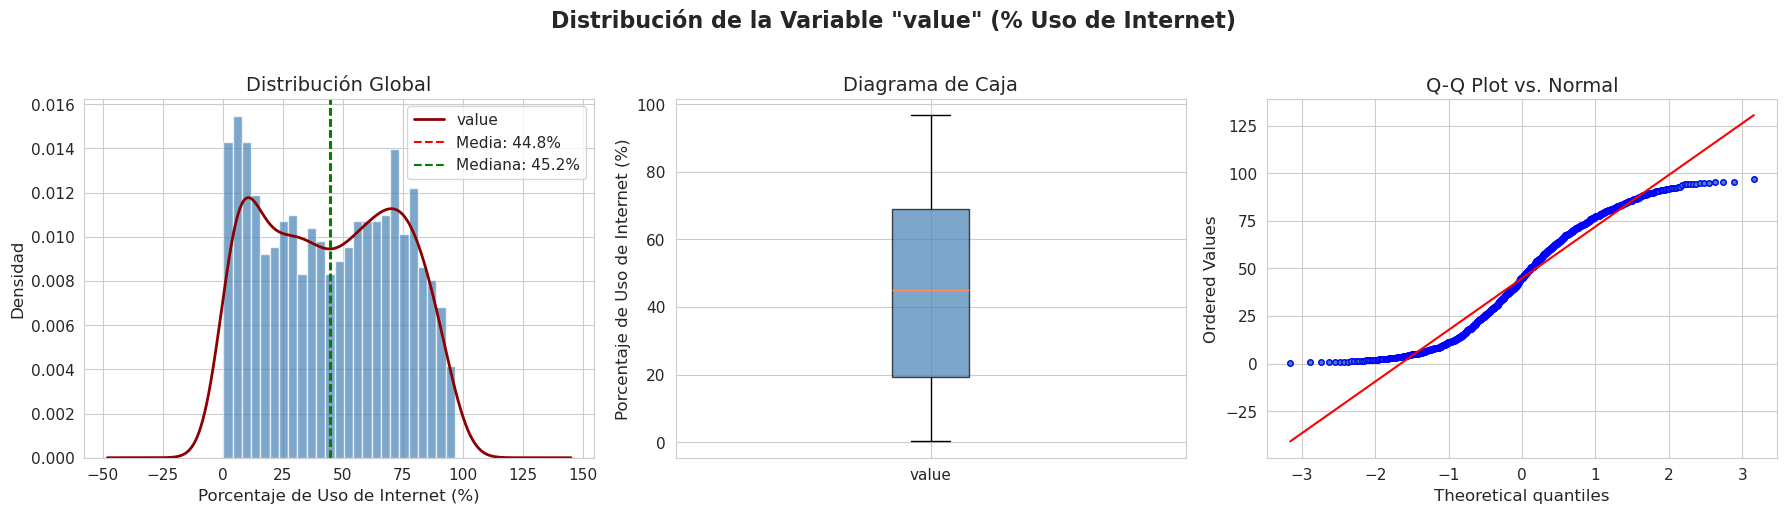

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma con KDE
axes[0].hist(df['value'], bins=25, edgecolor='white', alpha=0.7, color='steelblue', density=True)
df['value'].plot.kde(ax=axes[0], color='darkred', linewidth=2)
axes[0].axvline(df['value'].mean(), color='red', linestyle='--', label=f'Media: {df["value"].mean():.1f}%')
axes[0].axvline(df['value'].median(), color='green', linestyle='--', label=f'Mediana: {df["value"].median():.1f}%')
axes[0].set_xlabel('Porcentaje de Uso de Internet (%)')
axes[0].set_ylabel('Densidad')
axes[0].set_title('Distribución Global')
axes[0].legend()

# Boxplot
bp = axes[1].boxplot(df['value'], vert=True, patch_artist=True,
                      boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_ylabel('Porcentaje de Uso de Internet (%)')
axes[1].set_title('Diagrama de Caja')
axes[1].set_xticklabels(['value'])

# QQ-plot
sp_stats.probplot(df['value'], dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot vs. Normal')
axes[2].get_lines()[0].set_markerfacecolor('steelblue')
axes[2].get_lines()[0].set_markersize(4)

fig.suptitle('Distribución de la Variable "value" (% Uso de Internet)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Interpretación de la distribución global:**

- La distribución es **aproximadamente simétrica**, con la media y mediana casi coincidentes.
- Es **platikurtica** (curtosis negativa), lo que significa que los datos están más dispersos que una distribución normal, con colas mas ligeras.
- El Q-Q plot confirma que los datos se desvían de la normalidad en los extremos, lo cual es esperado para un porcentaje acotado entre 0 y 100.
- La ausencia de outliers extremos por el método IQR es consistente con la naturaleza acotada de la variable.

**Nota**: Esta distribución es global, **mezcla todas las dimensiones** (países, edades, años), lo que oculta la estructura real.

**Distribución por grupo etario**

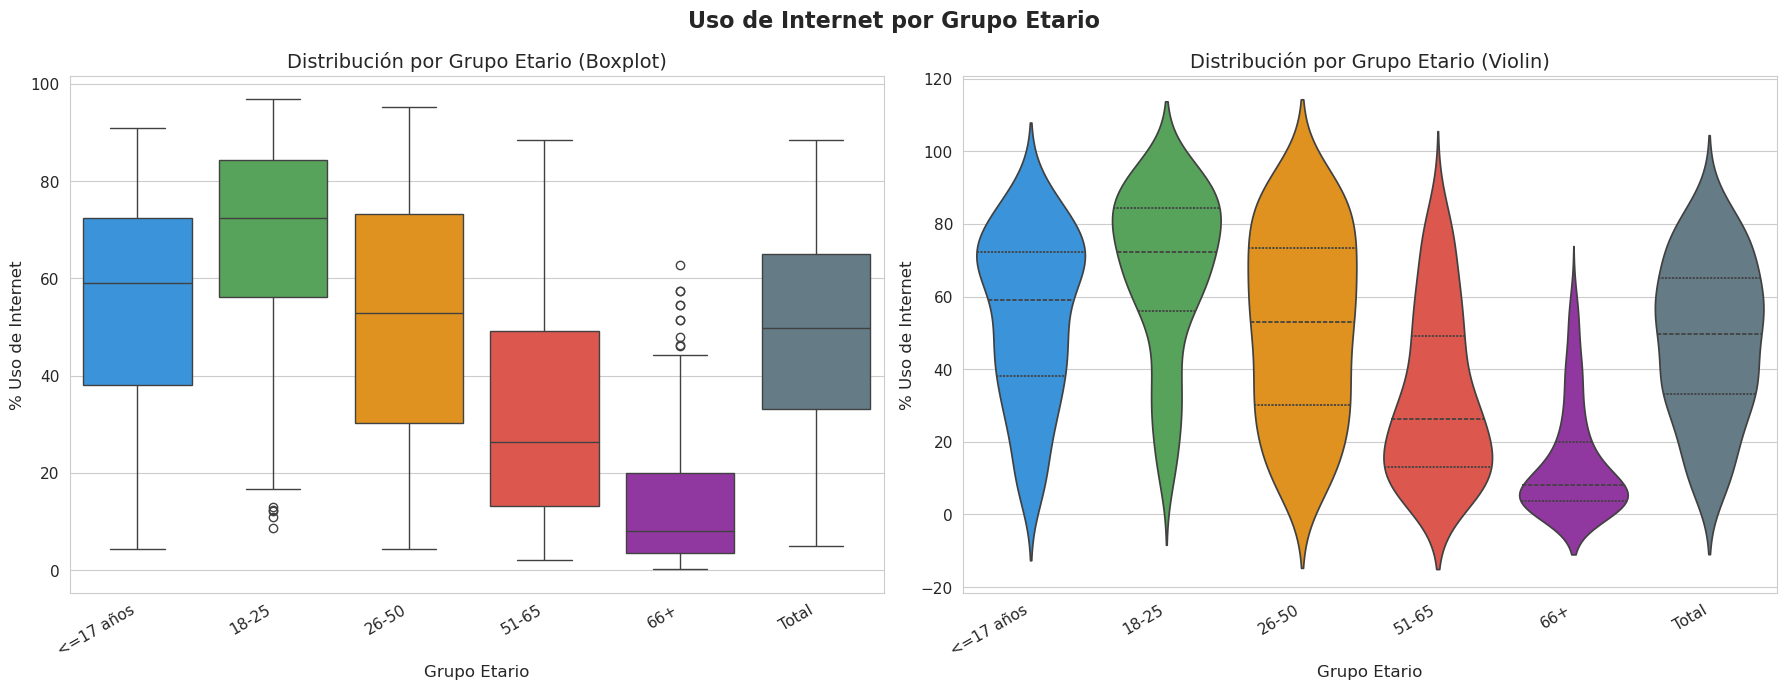


Estadísticas descriptivas por grupo etario:


,count,mean,std,min,25%,50%,75%,max
Grupos etarios Uso Internet,,,,,,,,
edad de medicion a 17 años,145.0,54.3,23.0,4.4,38.1,59.1,72.3,90.9
18 a 25 años de edad,145.0,66.8,22.9,8.6,56.1,72.3,84.4,96.8
26 a 50 años de edad,145.0,52.0,25.8,4.4,30.2,52.9,73.3,95.2
51 a 65 años,145.0,32.9,23.2,2.1,13.1,26.3,49.1,88.4
66 años en adelante,145.0,14.5,15.1,0.2,3.6,8.0,20.0,62.7
Total,145.0,48.3,21.5,5.0,33.1,49.7,65.0,88.5


In [49]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Boxplot por grupo etario
sns.boxplot(data=df, x='Grupos etarios Uso Internet', y='value',
            order=ORDEN_EDAD, palette=PALETA_EDAD, ax=axes[0])
axes[0].set_xticklabels([ETIQUETAS_CORTAS[g] for g in ORDEN_EDAD], rotation=30, ha='right')
axes[0].set_ylabel('% Uso de Internet')
axes[0].set_xlabel('Grupo Etario')
axes[0].set_title('Distribución por Grupo Etario (Boxplot)')

# Violin plot
sns.violinplot(data=df, x='Grupos etarios Uso Internet', y='value',
               order=ORDEN_EDAD, palette=PALETA_EDAD, ax=axes[1], inner='quartile')
axes[1].set_xticklabels([ETIQUETAS_CORTAS[g] for g in ORDEN_EDAD], rotation=30, ha='right')
axes[1].set_ylabel('% Uso de Internet')
axes[1].set_xlabel('Grupo Etario')
axes[1].set_title('Distribución por Grupo Etario (Violin)')

fig.suptitle('Uso de Internet por Grupo Etario', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Tabla de estadísticas por grupo etario
print('\nEstadísticas descriptivas por grupo etario:')
stats_edad = df.groupby('Grupos etarios Uso Internet')['value'].describe().round(1)
stats_edad = stats_edad.reindex(ORDEN_EDAD)
display(stats_edad)

**Distribución por país (ordenado por mediana)**

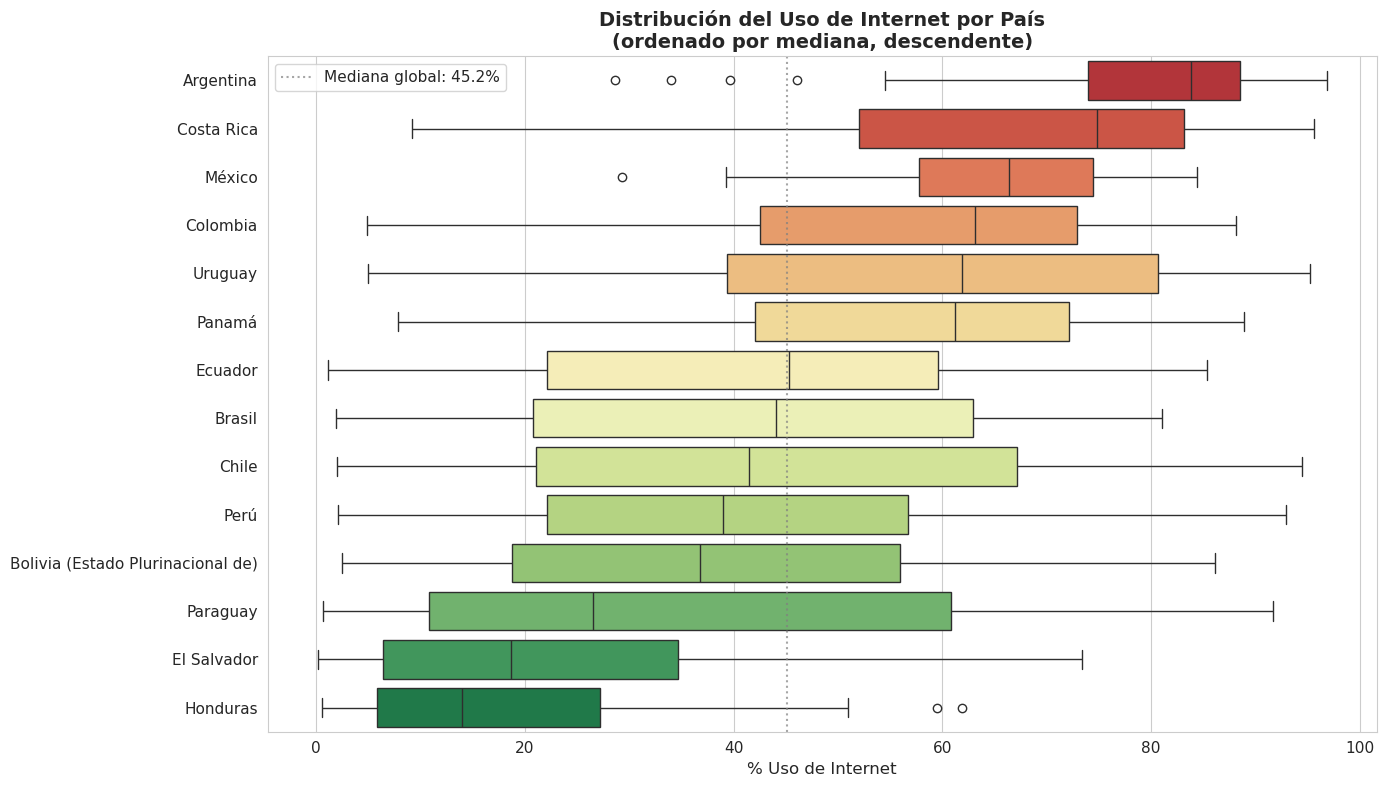


Estadísticas descriptivas por país:


,N,Media,Mediana,Desv.Est.,Min,Max
País__ESTANDAR,,,,,,
Argentina,42,77.7,83.8,17.0,28.6,96.8
Costa Rica,54,67.4,74.8,23.1,9.2,95.6
México,48,64.9,66.4,12.4,29.3,84.4
Colombia,60,55.8,63.2,23.5,4.9,88.1
Uruguay,72,58.6,61.9,26.0,5.0,95.2
Panamá,42,55.2,61.2,22.6,7.9,88.9
Ecuador,48,42.0,45.4,24.3,1.2,85.3
Brasil,48,41.3,44.0,23.8,1.9,81.0
Chile,48,44.1,41.5,28.2,2.0,94.4


In [50]:
medians_by_country = df.groupby('País__ESTANDAR')['value'].median().sort_values(ascending=False)
country_order = medians_by_country.index.tolist()

fig, ax = plt.subplots(figsize=(14, 8))
sns.boxplot(data=df, y='País__ESTANDAR', x='value', order=country_order,
            palette='RdYlGn', orient='h', ax=ax)
ax.set_xlabel('% Uso de Internet')
ax.set_ylabel('')
ax.set_title('Distribución del Uso de Internet por País\n(ordenado por mediana, descendente)',
             fontsize=14, fontweight='bold')
ax.axvline(df['value'].median(), color='gray', linestyle=':', alpha=0.7,
           label=f'Mediana global: {df["value"].median():.1f}%')
ax.legend()
plt.tight_layout()
plt.show()

# Tabla de estadísticas por país
print('\nEstadísticas descriptivas por país:')
stats_pais = df.groupby('País__ESTANDAR')['value'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
).round(1).sort_values('median', ascending=False)
stats_pais.columns = ['N', 'Media', 'Mediana', 'Desv.Est.', 'Min', 'Max']
display(stats_pais)

**Estadísticas por año**

Estadísticas descriptivas por año:


,N obs.,Media,Mediana,Desv.Est.,Min,Max
Años__ESTANDAR,,,,,,
2000,6,16.7,16.8,10.5,2.0,29.8
2003,6,24.8,24.8,15.7,3.1,44.3
2004,6,5.2,5.1,3.4,0.8,10.9
2005,18,10.4,8.1,9.1,0.6,31.3
2006,18,15.2,7.7,18.9,0.7,61.4
2007,18,14.2,10.4,14.5,0.2,55.1
2008,24,27.0,25.2,18.6,1.3,59.9
2009,54,25.8,21.9,19.9,0.7,68.2
2010,36,24.1,21.2,19.3,1.2,77.8


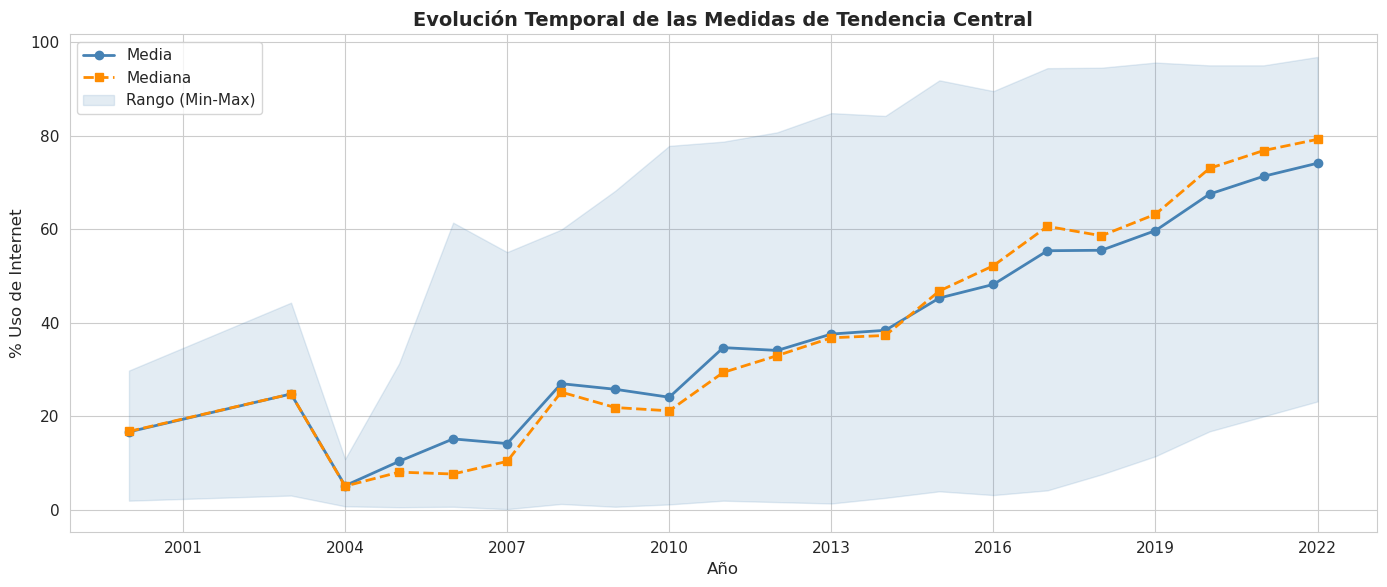

In [51]:
stats_year = df.groupby('Años__ESTANDAR')['value'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
).round(1)
stats_year.columns = ['N obs.', 'Media', 'Mediana', 'Desv.Est.', 'Min', 'Max']

print('Estadísticas descriptivas por año:')
display(stats_year)

# Tendencia temporal de medidas de tendencia central
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(stats_year.index, stats_year['Media'], 'o-', color='steelblue', label='Media', linewidth=2)
ax.plot(stats_year.index, stats_year['Mediana'], 's--', color='darkorange', label='Mediana', linewidth=2)
ax.fill_between(stats_year.index, stats_year['Min'], stats_year['Max'],
                alpha=0.15, color='steelblue', label='Rango (Min-Max)')
ax.set_xlabel('Año')
ax.set_ylabel('% Uso de Internet')
ax.set_title('Evolución Temporal de las Medidas de Tendencia Central', fontsize=14, fontweight='bold')
ax.legend()
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

**Nota**: La cantidad de observaciones por año varía significativamente (de 6 a 78), lo que afecta la representatividad de estas estadísticas agregadas.

#### 2.2 Hallazgos Clave de la Exploración Numérica

1. **Brecha digital intergeneracional clara:** El grupo 18-25 tiene la media más alta, mientras que el grupo 66+ tiene la más baja. La diferencia es de aproximadamente 52 puntos porcentuales.

2. **Alta variabilidad intra-grupo:** Todos los grupos etarios muestran desviaciones estándar superiores a 15 puntos, reflejando las diferencias entre países y la evolución temporal.

3. **Diferencias sustanciales entre países:** Los países con mayor acceso digital (como Chile y Argentina) contrastan marcadamente con los de menor acceso (como Honduras).

4. **Tendencia creciente sostenida:** La media global crece de forma constante a lo largo de los años, aunque con la advertencia de que los países que reportan en cada año son diferentes.

5. **Distribución platikurtica:** La variable `value` no sigue una distribución normal, se distribuye de forma más plana, consistente con un rango acotado [0, 100] y alta diversidad entre segmentos.

---
### 3. Exploración de Variables Categóricas

Las variables categóricas informativas del dataset son:
- **`País__ESTANDAR`**: 14 categorías (países)
- **`Grupos etarios Uso Internet`**: 6 categorías (grupos de edad)
- **`Años__ESTANDAR`**: 21 categorías (años, tratada como categórica temporal)

Las variables constantes (`indicator`, `unit`, `source_id`) y la variable nula (`notes_ids`) se excluyen de este análisis por no aportar variabilidad.

**Tabla de frecuencia: Países**

TABLA DE FRECUENCIA: País


,País,Frecuencia Absoluta,Frecuencia Relativa (%),Frecuencia Acumulada,Frec. Acum. Relativa (%)
0,Paraguay,102,11.72,102,11.72
1,Perú,96,11.03,198,22.76
2,El Salvador,72,8.28,270,31.03
3,Honduras,72,8.28,342,39.31
4,Uruguay,72,8.28,414,47.59
5,Bolivia (Estado Plurinacional de),66,7.59,480,55.17
6,Colombia,60,6.90,540,62.07
7,Costa Rica,54,6.21,594,68.28
8,Brasil,48,5.52,642,73.79
9,Chile,48,5.52,690,79.31


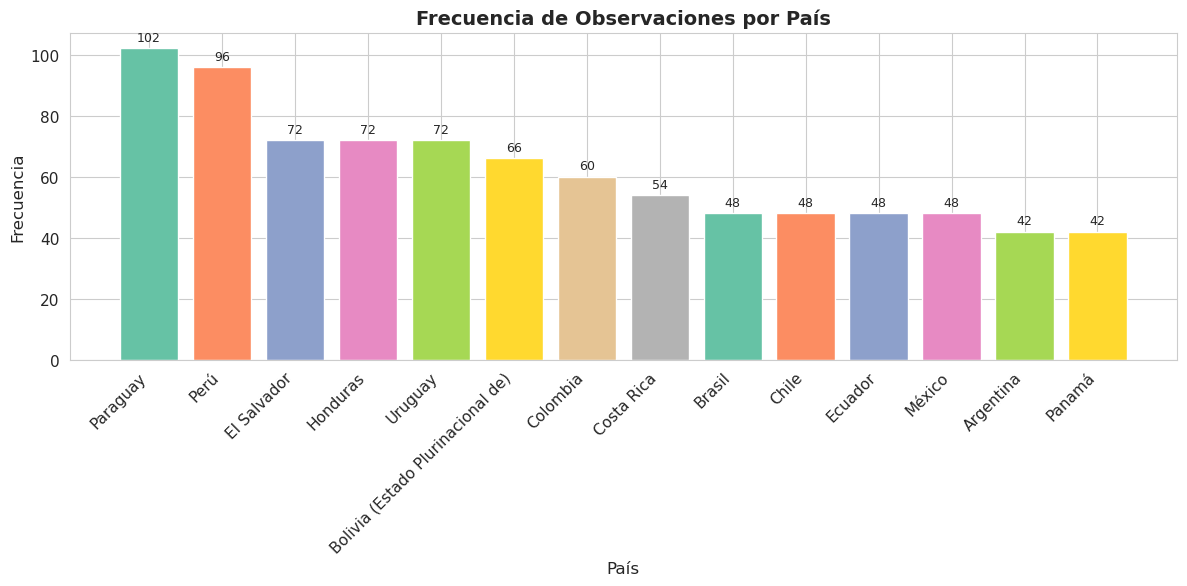

In [52]:
print('=' * 70)
print('TABLA DE FRECUENCIA: País')
print('=' * 70)

freq_pais = df['País__ESTANDAR'].value_counts().reset_index()
freq_pais.columns = ['País', 'Frecuencia Absoluta']
freq_pais['Frecuencia Relativa (%)'] = (freq_pais['Frecuencia Absoluta'] / len(df) * 100).round(2)
freq_pais['Frecuencia Acumulada'] = freq_pais['Frecuencia Absoluta'].cumsum()
freq_pais['Frec. Acum. Relativa (%)'] = (freq_pais['Frecuencia Acumulada'] / len(df) * 100).round(2)

display(freq_pais)

# Grafico de barras
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(freq_pais['País'], freq_pais['Frecuencia Absoluta'],
              color=sns.color_palette('Set2', len(freq_pais)))
ax.set_xlabel('País')
ax.set_ylabel('Frecuencia')
ax.set_title('Frecuencia de Observaciones por País', fontsize=14, fontweight='bold')
ax.bar_label(bars, padding=3, fontsize=9)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Nota**: La diferencia en frecuencias refleja la diferente cobertura temporal de cada país, no el tamaño del país. Países con más observaciones reportan datos para más años.

**Tabla de frecuencia: Grupos etarios**

TABLA DE FRECUENCIA: Grupo Etario


,Grupo Etario,Frecuencia Absoluta,Frecuencia Relativa (%)
0,edad de medicion a 17 años,145,16.67
1,18 a 25 años de edad,145,16.67
2,26 a 50 años de edad,145,16.67
3,51 a 65 años,145,16.67
4,66 años en adelante,145,16.67
5,Total,145,16.67


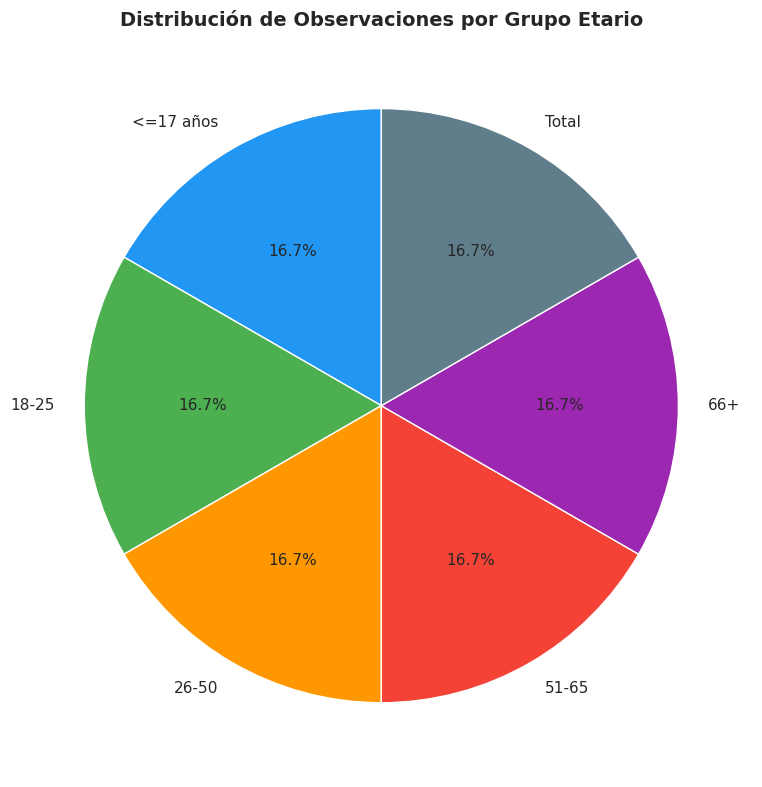

In [53]:
print('=' * 70)
print('TABLA DE FRECUENCIA: Grupo Etario')
print('=' * 70)

freq_edad = df['Grupos etarios Uso Internet'].value_counts().reindex(ORDEN_EDAD).reset_index()
freq_edad.columns = ['Grupo Etario', 'Frecuencia Absoluta']
freq_edad['Frecuencia Relativa (%)'] = (freq_edad['Frecuencia Absoluta'] / len(df) * 100).round(2)

display(freq_edad)

# Grafico de pastel
fig, ax = plt.subplots(figsize=(8, 8))
colors = [PALETA_EDAD[g] for g in freq_edad['Grupo Etario']]
labels = [ETIQUETAS_CORTAS[g] for g in freq_edad['Grupo Etario']]
ax.pie(freq_edad['Frecuencia Absoluta'], labels=labels, colors=colors,
       autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11})
ax.set_title('Distribución de Observaciones por Grupo Etario', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Todos los grupos etarios tienen exactamente la misma cantidad de observaciones (balance perfecto).

Esto se debe a que cada combinación país-año siempre incluye los 6 grupos etarios.

**Tabla de frecuencia: Años**

TABLA DE FRECUENCIA: Año


,Año,Frecuencia Absoluta,Frecuencia Relativa (%),Países que reportan
0,2000,6,0.69,1
1,2003,6,0.69,1
2,2004,6,0.69,1
3,2005,18,2.07,3
4,2006,18,2.07,3
5,2007,18,2.07,3
6,2008,24,2.76,4
7,2009,54,6.21,9
8,2010,36,4.14,6
9,2011,36,4.14,6


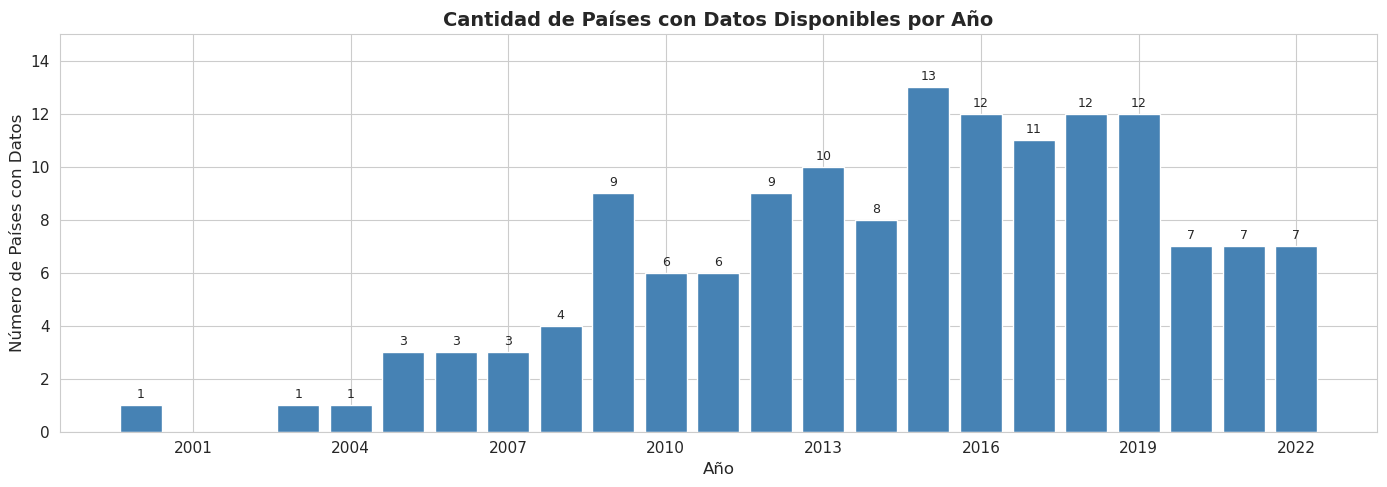

In [54]:
print('=' * 70)
print('TABLA DE FRECUENCIA: Año')
print('=' * 70)

freq_year = df['Años__ESTANDAR'].value_counts().sort_index().reset_index()
freq_year.columns = ['Año', 'Frecuencia Absoluta']
freq_year['Frecuencia Relativa (%)'] = (freq_year['Frecuencia Absoluta'] / len(df) * 100).round(2)
freq_year['Países que reportan'] = freq_year['Frecuencia Absoluta'] // 6  # 6 grupos etarios por pais

display(freq_year)

# Grafico de barras temporal
fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(freq_year['Año'], freq_year['Países que reportan'], color='steelblue', edgecolor='white')
ax.set_xlabel('Año')
ax.set_ylabel('Número de Países con Datos')
ax.set_title('Cantidad de Países con Datos Disponibles por Año', fontsize=14, fontweight='bold')
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_ylim(0, 15)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

**Tabla cruzada: qué años tiene cada país**

In [55]:
cross_tab = pd.crosstab(df['País__ESTANDAR'], df['Años__ESTANDAR'])
# Convertir a binario (tiene/no tiene datos)
cross_tab_bin = (cross_tab > 0).astype(int)

print('=' * 70)
print('TABLA CRUZADA: País x Año (presencia de datos)')
print('=' * 70)
display(cross_tab_bin)

# Resumir rango temporal por país
print('\nResumen temporal por país:')
resumen_temporal = pd.DataFrame({
    'Primer año': cross_tab_bin.apply(lambda row: row[row == 1].index.min(), axis=1),
    'Último año': cross_tab_bin.apply(lambda row: row[row == 1].index.max(), axis=1),
    'Años con datos': cross_tab_bin.sum(axis=1),
    'Rango temporal': cross_tab_bin.apply(
        lambda row: row[row == 1].index.max() - row[row == 1].index.min(), axis=1
    )
}).sort_values('Años con datos', ascending=False)

display(resumen_temporal)

TABLA CRUZADA: País x Año (presencia de datos)


Años__ESTANDAR,2000,2003,2004,2005,2006,2007,2008,2009,2010,2011,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
País__ESTANDAR,,,,,,,,,,,,,,,,,,,,,
Argentina,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,1,1,1,1,1,1
Bolivia (Estado Plurinacional de),0,0,0,0,0,0,0,1,0,0,...,1,1,1,1,1,1,1,1,1,0
Brasil,0,0,0,1,0,0,1,1,0,1,...,1,1,1,0,0,0,0,0,0,0
Chile,1,1,0,0,1,0,0,1,0,1,...,1,0,1,0,1,0,0,0,0,0
Colombia,0,0,0,0,0,0,0,0,0,0,...,1,1,1,1,0,1,1,1,1,1
Costa Rica,0,0,0,0,0,0,0,0,0,0,...,0,0,1,1,1,1,1,1,1,1
Ecuador,0,0,0,0,0,0,0,1,1,0,...,1,0,1,1,1,1,1,0,0,0
El Salvador,0,0,0,0,1,1,0,1,1,0,...,1,1,1,1,1,1,1,0,0,0
Honduras,0,0,1,1,0,0,0,1,1,1,...,1,1,1,1,0,1,1,0,0,0



Resumen temporal por país:


,Primer año,Último año,Años con datos,Rango temporal
País__ESTANDAR,,,,
Paraguay,2005,2022,17,17
Perú,2007,2022,16,15
Honduras,2004,2019,12,15
El Salvador,2006,2019,12,13
Uruguay,2008,2019,12,11
Bolivia (Estado Plurinacional de),2009,2021,11,12
Colombia,2012,2022,10,10
Costa Rica,2012,2022,9,10
Chile,2000,2017,8,17


#### 3.1 Hallazgos de la Exploración Categórica

1. **Balance perfecto por grupo etario:** Cada grupo etario tiene exactamente la misma cantidad de observaciones. Esto es un resultado natural de la estructura: cada país-año siempre reporta los 6 grupos.

2. **Desbalance significativo por país:** Algunos países tienen más del doble de observaciones que otros. Esto se debe a la diferente cobertura temporal, no al tamaño del país.

3. **Cobertura temporal fragmentada:**
   - Los primeros años (2000, 2003) solo tienen datos de 1-2 países.
   - El período con mayor cobertura es aproximadamente 2015-2019.
   - Los años más recientes (2020-2022) tienen cobertura reducida.
   
4. **Implicación para análisis:** Las comparaciones temporales deben hacerse con cuidado, ya que la composición de países cambia de año a año. Un promedio simple por año mezcla países con diferentes niveles de desarrollo digital.

---
### 4. Relaciones entre las Variables

Dado que el dataset tiene una sola variable numérica (`value`) y tres variables categóricas que definen las dimensiones del panel, las relaciones a explorar son:

1. **value vs. Grupo Etario** (brecha digital intergeneracional)
2. **value vs. País** (brecha digital entre países)
3. **value vs. Año** (evolución temporal / adopción digital)
4. **Interacciones**: País x Grupo Etario, Grupo Etario x Año, País x Año

**Evolución temporal por grupo etario**

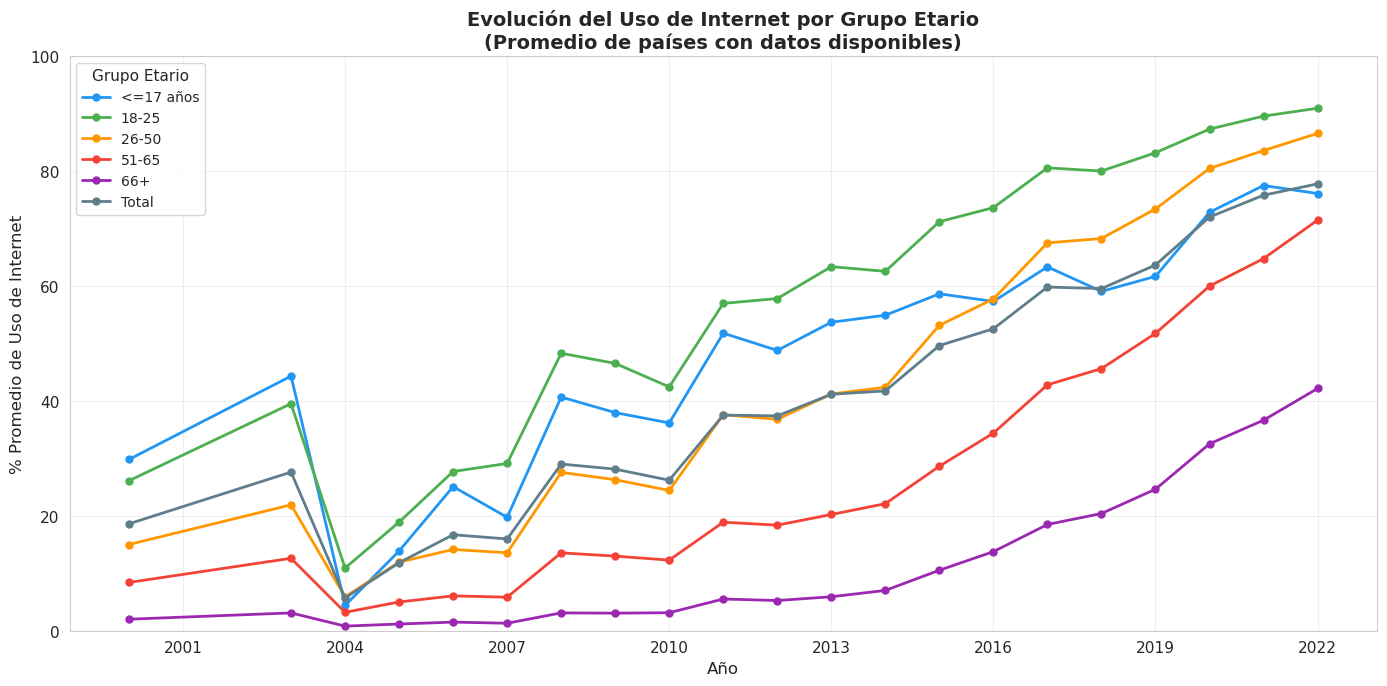

In [56]:
fig, ax = plt.subplots(figsize=(14, 7))

for grupo in ORDEN_EDAD:
    grupo_data = df[df['Grupos etarios Uso Internet'] == grupo]
    yearly_mean = grupo_data.groupby('Años__ESTANDAR')['value'].mean()
    label = ETIQUETAS_CORTAS[grupo]
    ax.plot(yearly_mean.index, yearly_mean.values, 'o-',
            color=PALETA_EDAD[grupo], label=label, linewidth=2, markersize=5)

ax.set_xlabel('Año')
ax.set_ylabel('% Promedio de Uso de Internet')
ax.set_title('Evolución del Uso de Internet por Grupo Etario\n(Promedio de países con datos disponibles)',
             fontsize=14, fontweight='bold')
ax.legend(title='Grupo Etario', loc='upper left', fontsize=10)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Nota**: El promedio anual incluye diferentes países en cada año. Las fluctuaciones pueden deberse a cambios en la composición de países, no a cambios reales.

**Small multiples: evolución por país (todos los grupos etarios)**

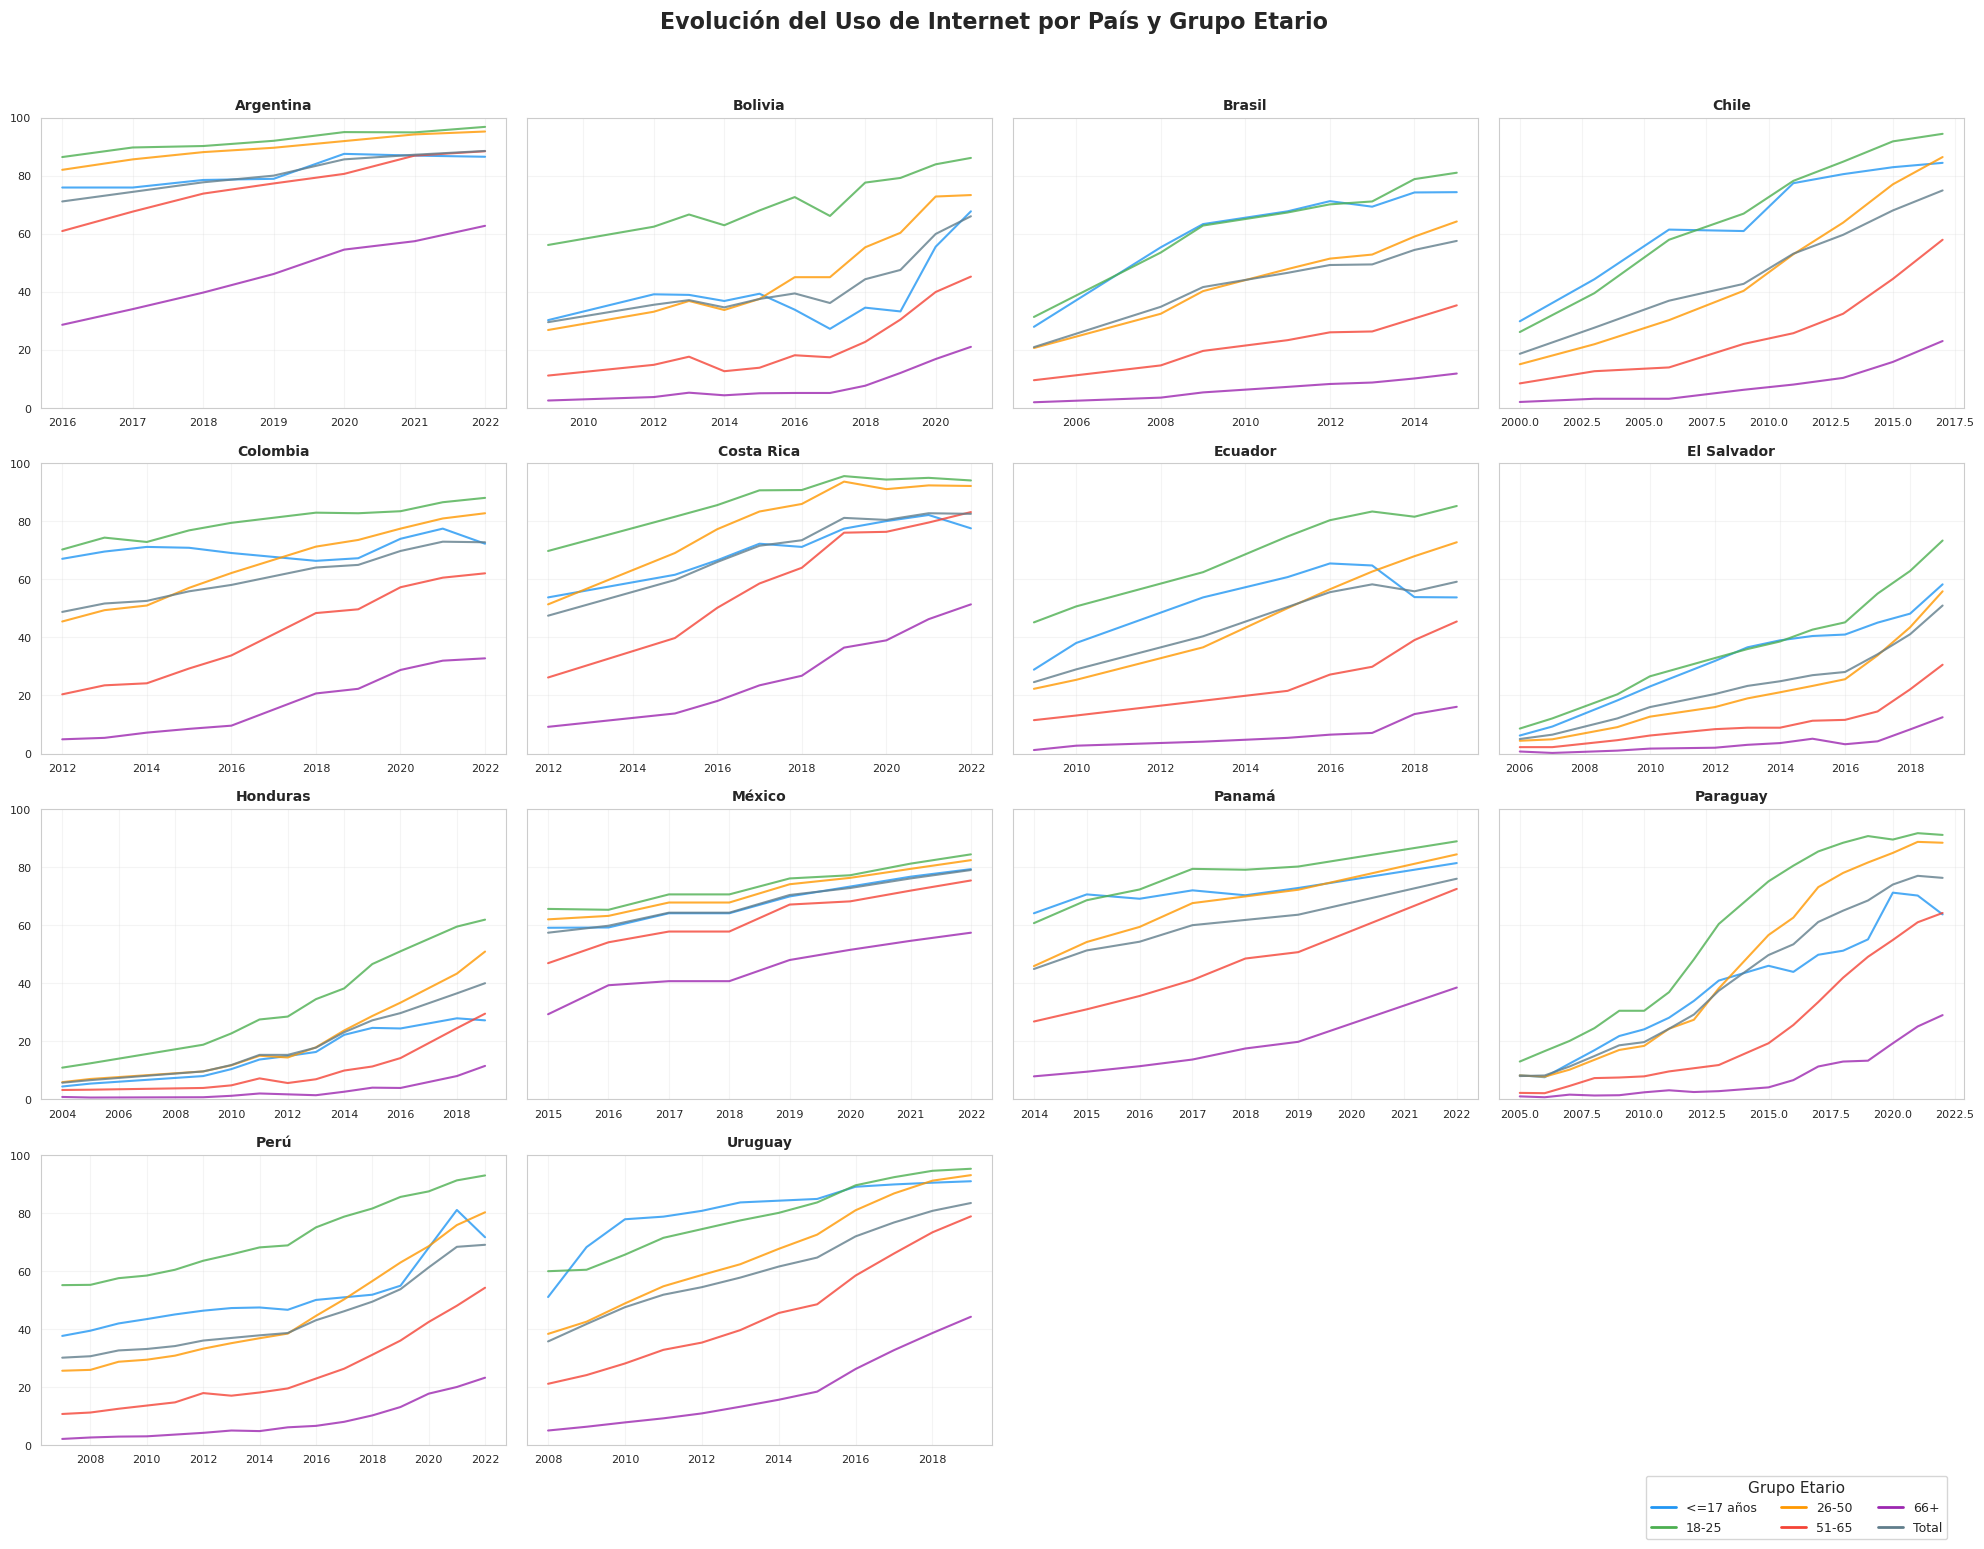

In [57]:
from matplotlib.lines import Line2D

countries = sorted(df['País__ESTANDAR'].unique())
fig, axes = plt.subplots(4, 4, figsize=(20, 16), sharex=False, sharey=True)
axes_flat = axes.flatten()

for i, country in enumerate(countries):
    ax = axes_flat[i]
    cdf = df[df['País__ESTANDAR'] == country]

    for grupo in ORDEN_EDAD:
        gdf = cdf[cdf['Grupos etarios Uso Internet'] == grupo].sort_values('Años__ESTANDAR')
        if len(gdf) > 0:
            ax.plot(gdf['Años__ESTANDAR'], gdf['value'], '-',
                    color=PALETA_EDAD[grupo], linewidth=1.5, alpha=0.8)

    short_name = country.replace('Bolivia (Estado Plurinacional de)', 'Bolivia')
    ax.set_title(short_name, fontsize=10, fontweight='bold')
    ax.set_ylim(0, 100)
    ax.tick_params(labelsize=8)
    ax.grid(True, alpha=0.2)

# Ocultar ejes vacios
for j in range(len(countries), len(axes_flat)):
    axes_flat[j].set_visible(False)

# Leyenda compartida
handles = [
    Line2D([0], [0], color=PALETA_EDAD[g], linewidth=2, label=ETIQUETAS_CORTAS[g])
    for g in ORDEN_EDAD
]
fig.legend(handles=handles, loc='lower right', ncol=3, fontsize=9, title='Grupo Etario',
           bbox_to_anchor=(0.98, 0.02))

fig.suptitle('Evolución del Uso de Internet por País y Grupo Etario', fontsize=16, fontweight='bold')
plt.tight_layout(rect=(0, 0.06, 1, 0.96))
plt.show()

**Heatmap: valor promedio por país y grupo etario**

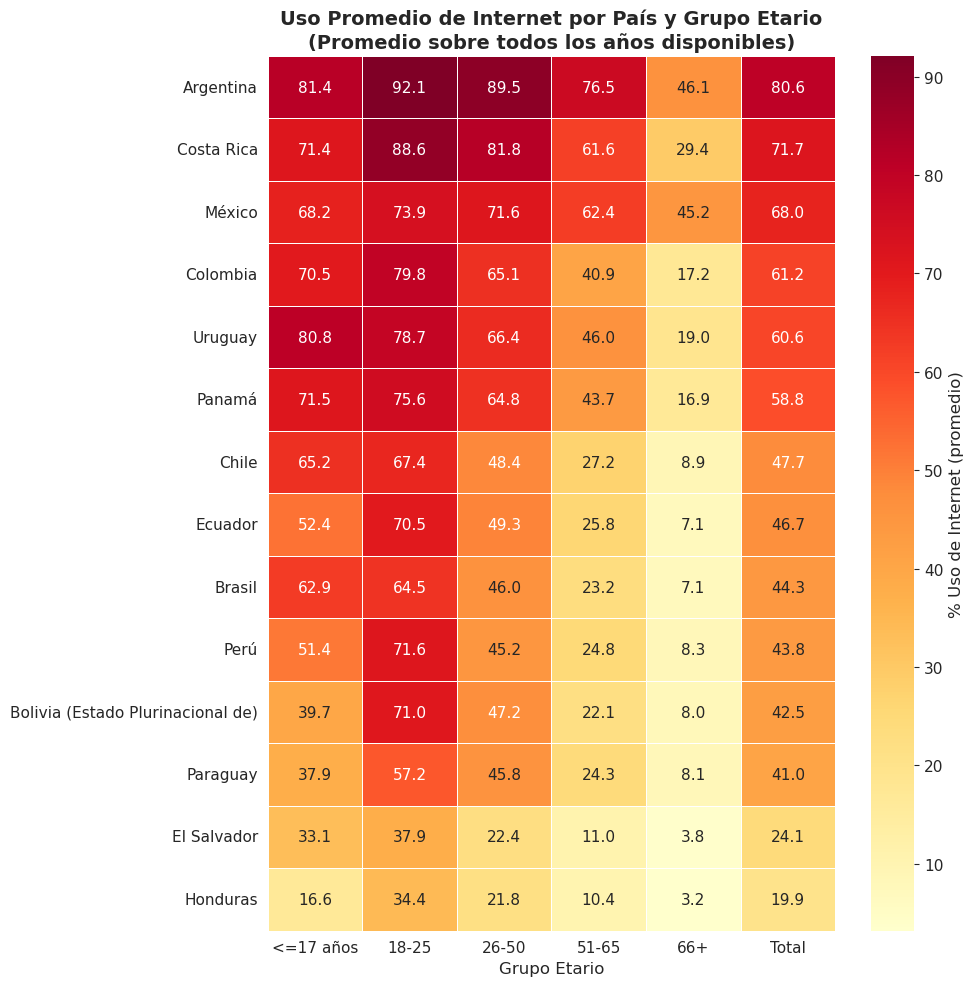

In [58]:
pivot_mean = df.pivot_table(values='value', index='País__ESTANDAR',
                             columns='Grupos etarios Uso Internet', aggfunc='mean')
pivot_mean = pivot_mean.reindex(columns=ORDEN_EDAD)

# Renombrar columnas para visualización
short_cols = [ETIQUETAS_CORTAS[g] for g in ORDEN_EDAD]
pivot_display = pivot_mean.copy()
pivot_display.columns = short_cols

# Ordenar por Total descendente
pivot_display = pivot_display.sort_values('Total', ascending=False)

fig, ax = plt.subplots(figsize=(10, 10))
sns.heatmap(pivot_display.round(1), annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label': '% Uso de Internet (promedio)'})
ax.set_title('Uso Promedio de Internet por País y Grupo Etario\n(Promedio sobre todos los años disponibles)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('')
ax.set_xlabel('Grupo Etario')
plt.tight_layout()
plt.show()

**Brecha digital: joven vs mayor (último año disponible por país)**

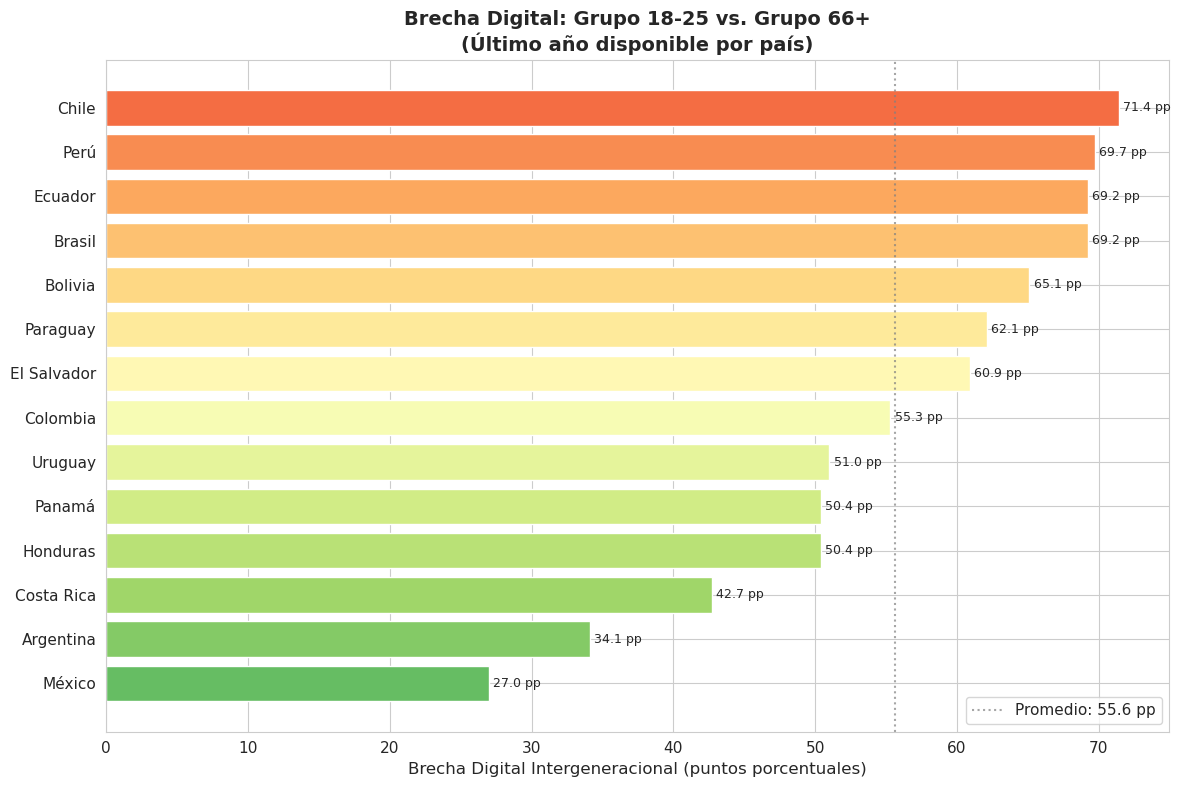

Tabla de brecha digital intergeneracional:


,Año más reciente,18-25 (%),66+ (%),Brecha (pp)
País,,,,
México,2022,84.4,57.4,27.0
Argentina,2022,96.8,62.7,34.1
Costa Rica,2022,94.1,51.4,42.7
Honduras,2019,61.9,11.5,50.4
Panamá,2022,88.9,38.5,50.4
Uruguay,2019,95.2,44.2,51.0
Colombia,2022,88.1,32.8,55.3
El Salvador,2019,73.4,12.5,60.9
Paraguay,2022,91.1,29.0,62.1


In [59]:
latest_data = df.sort_values('Años__ESTANDAR').groupby(
    ['País__ESTANDAR', 'Grupos etarios Uso Internet']
).last().reset_index()

brecha = []
for country in countries:
    cdata = latest_data[latest_data['País__ESTANDAR'] == country]
    young = cdata[cdata['Grupos etarios Uso Internet'] == '18 a 25 años de edad']['value'].values
    old = cdata[cdata['Grupos etarios Uso Internet'] == '66 años en adelante']['value'].values
    year = cdata['Años__ESTANDAR'].max()
    if len(young) > 0 and len(old) > 0:
        brecha.append({
            'País': country.replace('Bolivia (Estado Plurinacional de)', 'Bolivia'),
            'Año más reciente': year,
            '18-25 (%)': round(young[0], 1),
            '66+ (%)': round(old[0], 1),
            'Brecha (pp)': round(young[0] - old[0], 1)
        })

df_brecha = pd.DataFrame(brecha).sort_values('Brecha (pp)', ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
cmap = plt.get_cmap('RdYlGn_r')
colors = cmap(np.linspace(0.2, 0.8, len(df_brecha)))
bars = ax.barh(df_brecha['País'], df_brecha['Brecha (pp)'], color=colors)
ax.set_xlabel('Brecha Digital Intergeneracional (puntos porcentuales)')
ax.set_title('Brecha Digital: Grupo 18-25 vs. Grupo 66+\n(Último año disponible por país)',
             fontsize=14, fontweight='bold')
ax.bar_label(bars, fmt='%.1f pp', padding=3, fontsize=9)
ax.axvline(df_brecha['Brecha (pp)'].mean(), color='gray', linestyle=':', alpha=0.7,
           label=f'Promedio: {df_brecha["Brecha (pp)"].mean():.1f} pp')
ax.legend()
plt.tight_layout()
plt.show()

print('Tabla de brecha digital intergeneracional:')
display(df_brecha.set_index('País'))

**Análisis de varianza explicada (eta-cuadrado)**

ANÁLISIS DE VARIANZA EXPLICADA (eta-cuadrado)
¿Qué dimensión explica más la variabilidad en el uso de Internet?

  País                : eta2 = 0.3295 (32.9% de la varianza)
  Grupo Etario        : eta2 = 0.3669 (36.7% de la varianza)
  Año                 : eta2 = 0.3678 (36.8% de la varianza)

  Total explicado     : 106.4%
  (Los factores no son independientes; la suma puede exceder 100%)


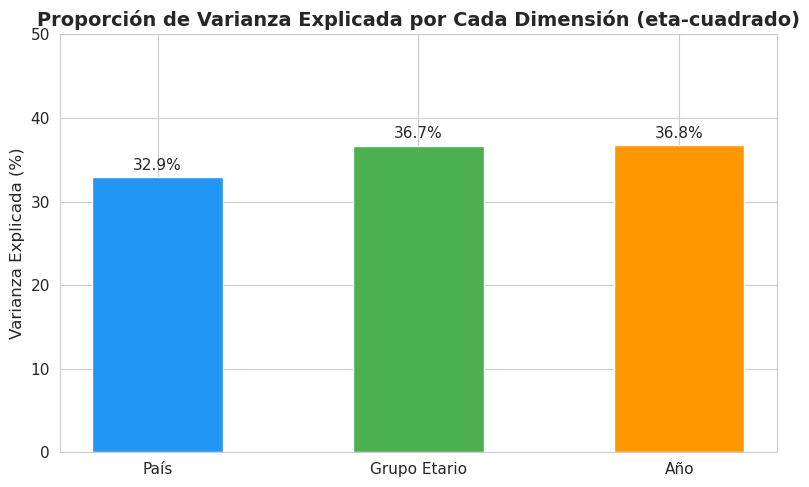

In [60]:
print('=' * 70)
print('ANÁLISIS DE VARIANZA EXPLICADA (eta-cuadrado)')
print('=' * 70)
print('¿Qué dimensión explica más la variabilidad en el uso de Internet?\n')

overall_var = df['value'].var()
results = {}
for col, label in [('País__ESTANDAR', 'País'),
                    ('Grupos etarios Uso Internet', 'Grupo Etario'),
                    ('Años__ESTANDAR', 'Año')]:
    groups = df.groupby(col)['value']
    between = sum(len(g) * (g.mean() - df['value'].mean())**2 for _, g in groups) / len(df)
    eta_sq = between / overall_var
    results[label] = eta_sq
    print(f'  {label:20s}: eta2 = {eta_sq:.4f} ({eta_sq*100:.1f}% de la varianza)')

print(f'\n  {"Total explicado":20s}: {sum(results.values())*100:.1f}%')
print(f'  (Los factores no son independientes; la suma puede exceder 100%)')

# Visualizar
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(list(results.keys()), [v * 100 for v in results.values()],
              color=['#2196F3', '#4CAF50', '#FF9800'], edgecolor='white', width=0.5)
ax.set_ylabel('Varianza Explicada (%)')
ax.set_title('Proporción de Varianza Explicada por Cada Dimensión (eta-cuadrado)',
             fontsize=14, fontweight='bold')
ax.bar_label(bars, fmt='%.1f%%', padding=3)
ax.set_ylim(0, 50)
plt.tight_layout()
plt.show()

**Correlación año-valor por segmento**

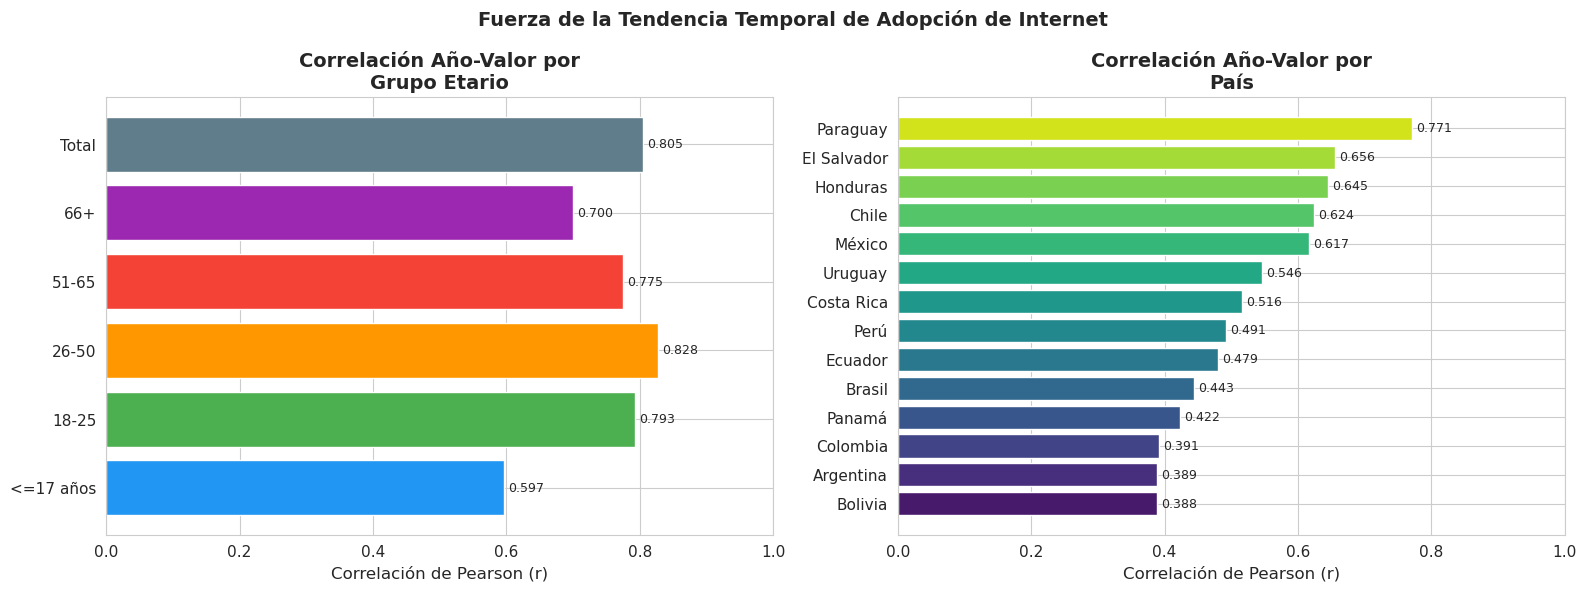

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Por grupo etario
corr_edad = {}
for grupo in ORDEN_EDAD:
    gdf = df[df['Grupos etarios Uso Internet'] == grupo]
    r = gdf[['Años__ESTANDAR', 'value']].corr().iloc[0, 1]
    label = ETIQUETAS_CORTAS[grupo]
    corr_edad[label] = r

bars1 = axes[0].barh(list(corr_edad.keys()), list(corr_edad.values()),
                      color=[PALETA_EDAD[g] for g in ORDEN_EDAD])
axes[0].set_xlabel('Correlación de Pearson (r)')
axes[0].set_title('Correlación Año-Valor por\nGrupo Etario', fontweight='bold')
axes[0].bar_label(bars1, fmt='%.3f', padding=3, fontsize=9)
axes[0].set_xlim(0, 1)

# Por pais
corr_pais = {}
for country in sorted(df['País__ESTANDAR'].unique()):
    cdf = df[df['País__ESTANDAR'] == country]
    r = cdf[['Años__ESTANDAR', 'value']].corr().iloc[0, 1]
    short = country.replace('Bolivia (Estado Plurinacional de)', 'Bolivia')
    corr_pais[short] = r

corr_pais_sorted = dict(sorted(corr_pais.items(), key=lambda x: x[1]))
bars2 = axes[1].barh(list(corr_pais_sorted.keys()), list(corr_pais_sorted.values()),
                      color=sns.color_palette('viridis', len(corr_pais_sorted)))
axes[1].set_xlabel('Correlación de Pearson (r)')
axes[1].set_title('Correlación Año-Valor por\nPaís', fontweight='bold')
axes[1].bar_label(bars2, fmt='%.3f', padding=3, fontsize=9)
axes[1].set_xlim(0, 1)

fig.suptitle('Fuerza de la Tendencia Temporal de Adopción de Internet', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Todas las correlaciones son positivas: el uso de Internet crece con el tiempo en todos los segmentos.

**Scatter plot con regresión por grupo etario**

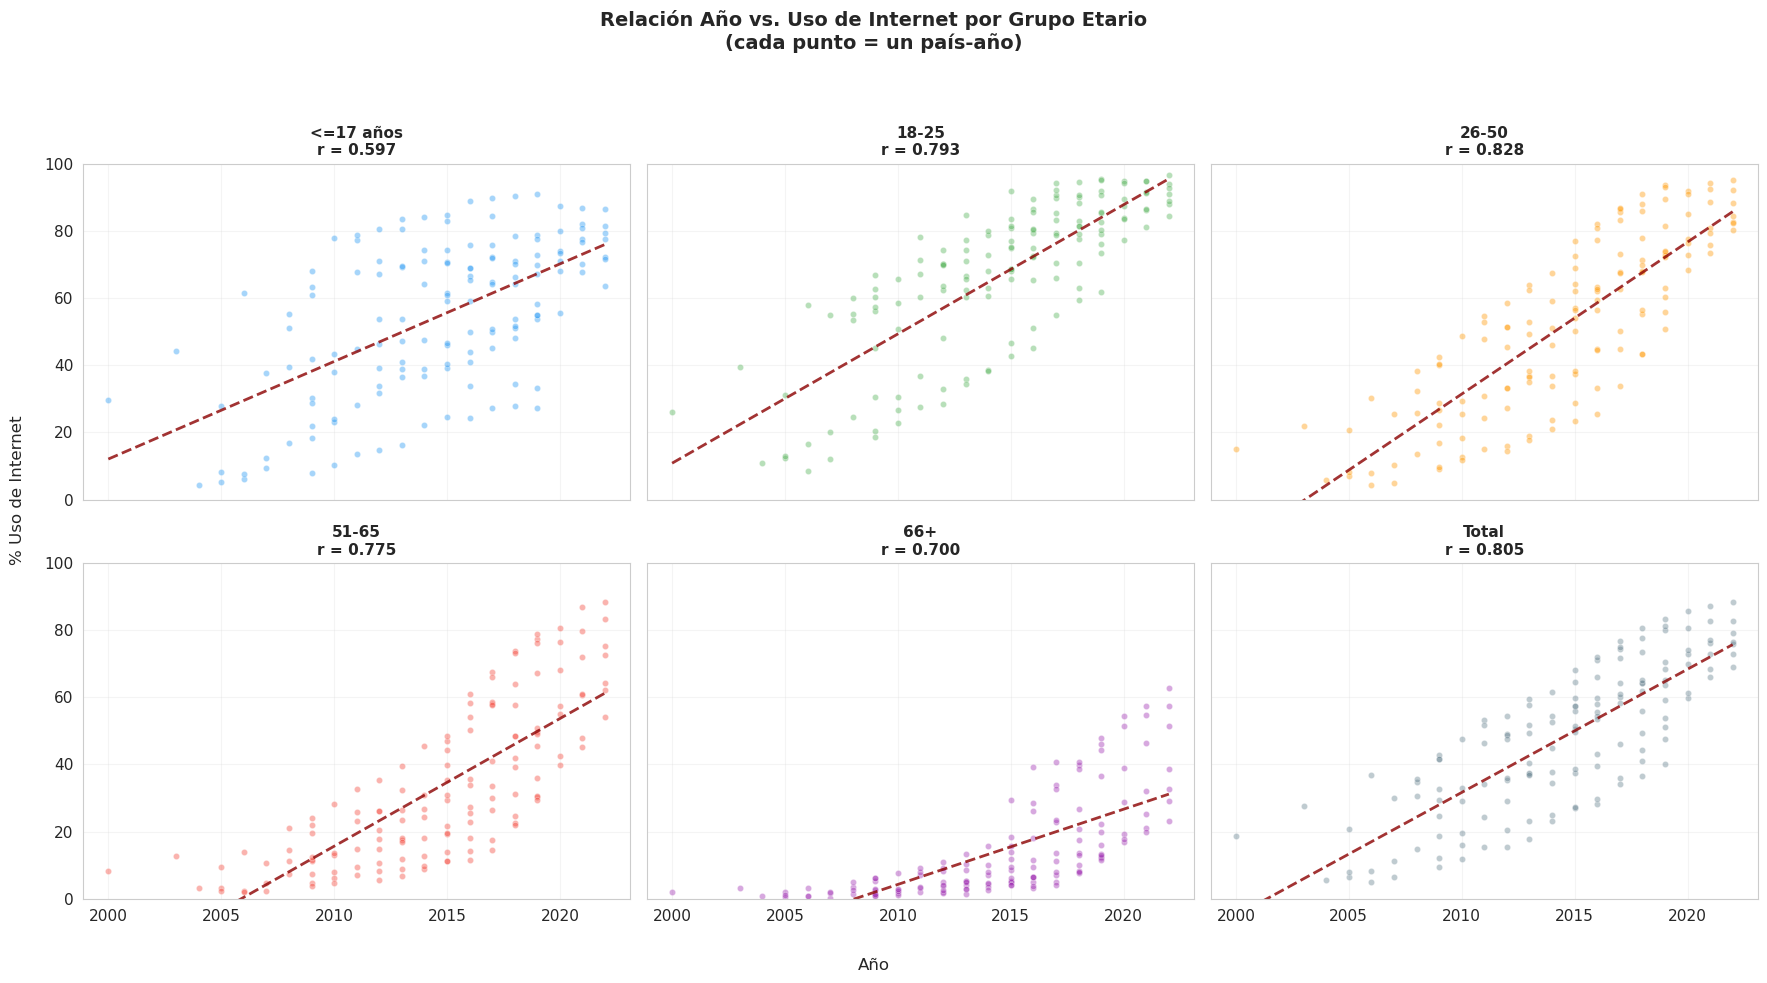

In [62]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
axes_flat = axes.flatten()

for i, grupo in enumerate(ORDEN_EDAD):
    ax = axes_flat[i]
    gdf = df[df['Grupos etarios Uso Internet'] == grupo]

    ax.scatter(gdf['Años__ESTANDAR'], gdf['value'], alpha=0.4, s=20,
               color=PALETA_EDAD[grupo], edgecolors='white', linewidth=0.5)

    # Linea de tendencia
    z = np.polyfit(gdf['Años__ESTANDAR'], gdf['value'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(gdf['Años__ESTANDAR'].min(), gdf['Años__ESTANDAR'].max(), 100)
    ax.plot(x_line, p(x_line), '--', color='darkred', linewidth=2, alpha=0.8)

    label = ETIQUETAS_CORTAS[grupo]
    r = gdf[['Años__ESTANDAR', 'value']].corr().iloc[0, 1]
    ax.set_title(f'{label}\nr = {r:.3f}', fontsize=11, fontweight='bold')
    ax.set_ylim(0, 100)
    ax.grid(True, alpha=0.2)

fig.suptitle('Relación Año vs. Uso de Internet por Grupo Etario\n(cada punto = un país-año)',
             fontsize=14, fontweight='bold')
fig.text(0.5, 0.02, 'Año', ha='center', fontsize=12)
fig.text(0.02, 0.5, '% Uso de Internet', va='center', rotation='vertical', fontsize=12)
plt.tight_layout(rect=(0.03, 0.05, 1, 0.94))
plt.show()

**Heatmap temporal: evolución por país (solo grupo 'Total')**

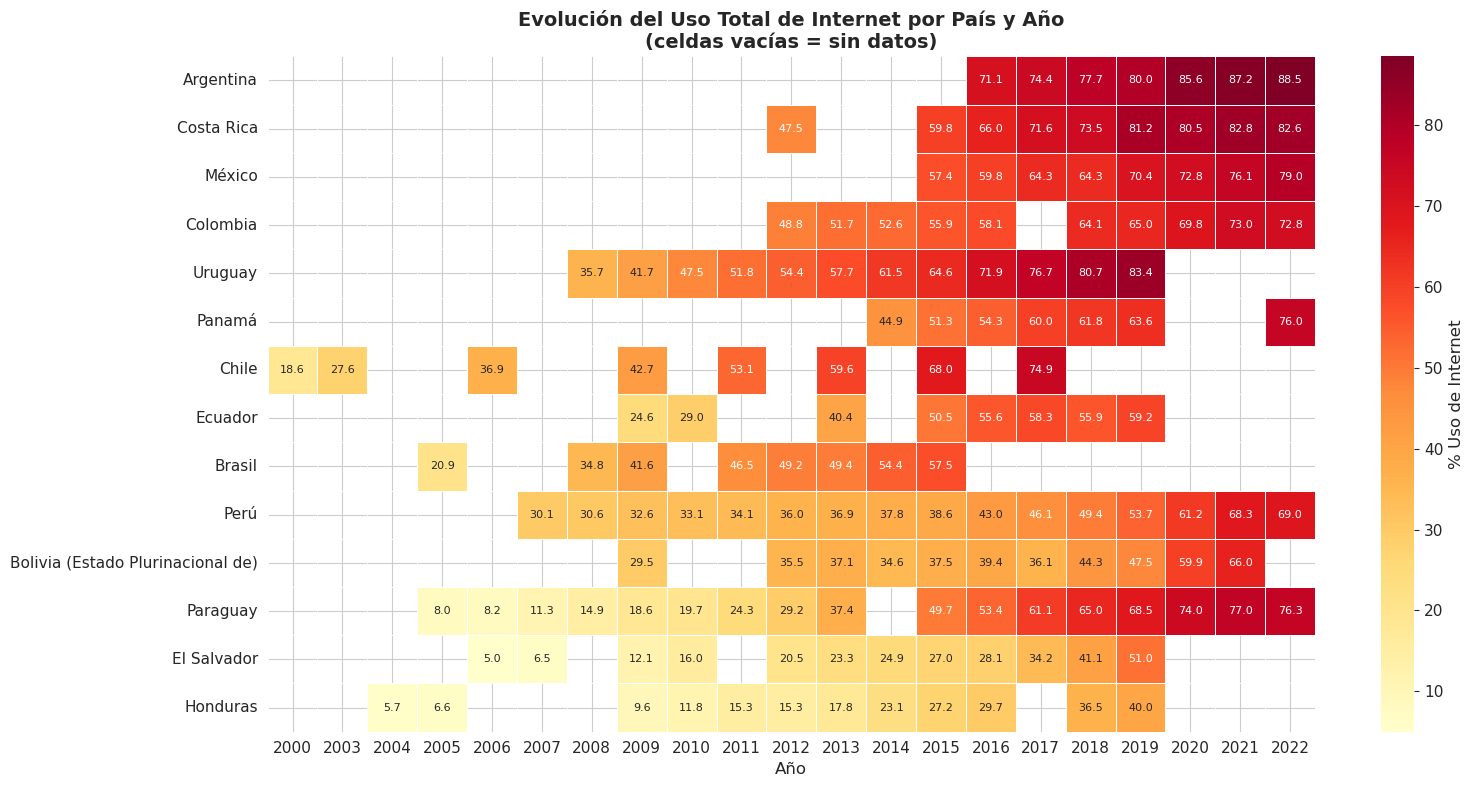

In [63]:
df_total = df[df['Grupos etarios Uso Internet'] == 'Total']
pivot_time = df_total.pivot_table(values='value', index='País__ESTANDAR',
                                   columns='Años__ESTANDAR', aggfunc='mean')

# Ordenar paises por valor promedio
pivot_time = pivot_time.reindex(pivot_time.mean(axis=1).sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(pivot_time.round(1), annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white', ax=ax,
            mask=pivot_time.isnull(),
            cbar_kws={'label': '% Uso de Internet'},
            annot_kws={'fontsize': 8})
ax.set_title('Evolución del Uso Total de Internet por País y Año\n(celdas vacías = sin datos)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('')
ax.set_xlabel('Año')
plt.tight_layout()
plt.show()

#### 4.1 Hallazgos sobre las Relaciones entre Variables

1. **Las tres dimensiones explican proporciones similares de varianza** (aproximadamente un tercio cada una). No hay una dimensión dominante; el uso de Internet depende por igual del país, el grupo etario y el año.

2. **Tendencia temporal positiva universal:** Todos los países y todos los grupos etarios muestran correlación positiva con el tiempo. La adopción de Internet es un fenómeno generalizado en la región.

3. **Velocidad de adopción desigual:**
   - El grupo 26-50 tiende a tener la tendencia temporal mas fuerte.
   - El grupo <=17 tiende a tener la más débil, posiblemente porque partía de niveles relativamente altos.

4. **Brecha digital intergeneracional persistente:**
   - La brecha promedio entre jóvenes (18-25) y adultos mayores (66+) es sustancial.
   - La magnitud de esta brecha varía significativamente entre países.
   
5. **Patrón de convergencia parcial:**
   - Los países con menores niveles iniciales de adopción crecen a tasas similares o mayores.
   - Sin embargo, la brecha entre países líderes y rezagados sigue siendo sustancial.